<a href="https://colab.research.google.com/github/Madvillainism/Amaterasu-/blob/main/ZeldaRecorder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Extracted Melody Sequence:
['B4', 'A4', 'F4', 'B4', 'A4', 'F4', 'B4', 'A4', 'E4', 'D4', 'E4', 'REST']


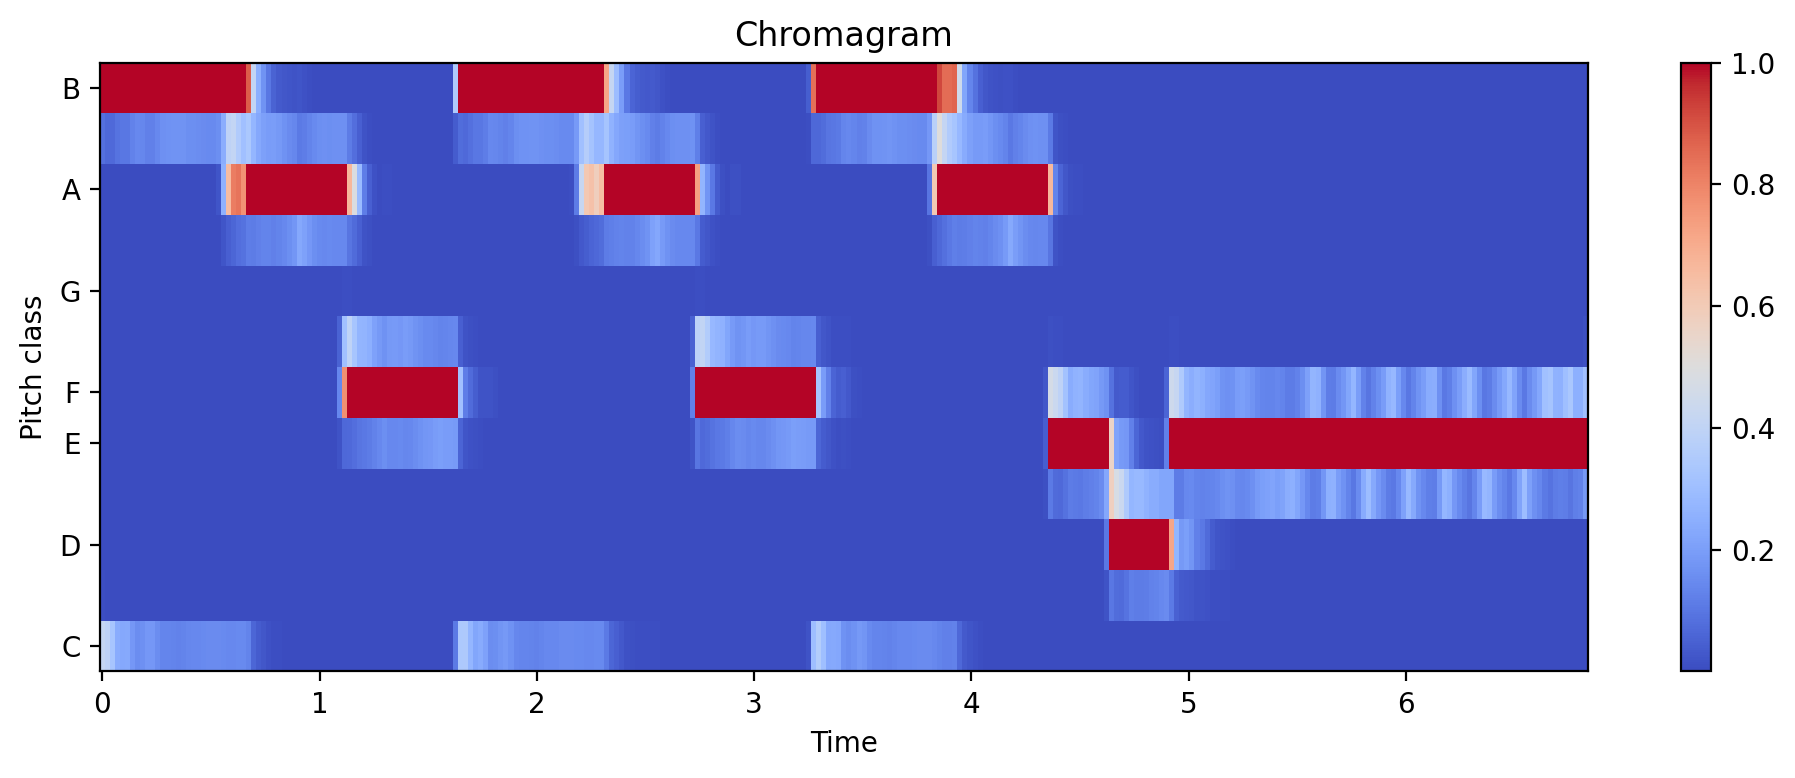

array([[4.1638473e-01, 3.9065668e-01, 3.2508147e-01, ..., 1.2327007e-04,
        1.5751689e-04, 1.0749744e-03],
       [6.0184333e-03, 3.8330932e-03, 2.4523917e-03, ..., 1.3999116e-05,
        1.1929771e-04, 1.6128324e-03],
       [1.8199139e-04, 1.5297694e-05, 2.2780707e-06, ..., 4.7749100e-04,
        8.9599047e-04, 6.1165011e-03],
       ...,
       [4.5183394e-04, 1.3105731e-04, 1.1829729e-04, ..., 7.3926612e-06,
        5.8378613e-05, 7.6421519e-04],
       [8.3690651e-02, 6.4499997e-02, 7.0274018e-02, ..., 8.9142421e-05,
        1.0671458e-04, 8.2749210e-04],
       [1.0000000e+00, 1.0000000e+00, 1.0000000e+00, ..., 6.9463614e-04,
        5.2585453e-04, 1.4749065e-03]], dtype=float32)

In [121]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import librosa.display
import scipy.signal as signal

def bandpass_filter(data, sr, lowcut=260, highcut=1100, order=5):
    nyquist = 0.5 * sr
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = signal.butter(order, [low, high], btype='band')
    return signal.lfilter(b, a, data)

# Apply the filter to your harmonic audio

def apply_noise_gate(y, threshold=0.01):
    y_gated = y.copy()
    y_gated[np.abs(y_gated) < threshold] = 0
    return y_gated

def transcribe_melody(file_path):
    # 1. Load the song
    min_duration_frames=3.5
    y, sr = librosa.load(file_path, duration=10.0)
    y_harmonic, y_percussive = librosa.effects.hpss(y)

    y_filtered = bandpass_filter(y_harmonic, sr)

    y_gated = apply_noise_gate(y_filtered, threshold=0.005)

    # 2. Extract fundamental frequency (f0)
    # Using fmin/fmax for a typical Soprano Recorder range (C4 to C6)
    fmin = librosa.note_to_hz('C3')
    fmax = librosa.note_to_hz('C7')
    f0, voiced_flag, _ = librosa.pyin(y_gated, fmin=fmin, fmax=fmax, sr=sr, frame_length=2064)

    # 3. Compress the output (Remove repeating notes)
    # This turns 1000 identical "C4" frames into one "C4" note
    melody_events = []
    current_note = None
    note_counter = 0

    for i, freq in enumerate(f0):
        if not voiced_flag[i]:
            note = "REST"
        else:
            note = librosa.hz_to_note((freq/2))

        # Only add to list if the note changed
        if note == current_note:
            note_counter += 1
        else:
            if current_note is not None and note_counter >= min_duration_frames:
                melody_events.append(current_note)
            note_counter = 1
            current_note = note

    # Add the last note
    if current_note is not None:
        melody_events.append(current_note)

    return melody_events

# Usage
notes = transcribe_melody('soh.mp3')
filtered_notes = [note for note in notes if '♯' not in note]
print("Extracted Melody Sequence:")
print(filtered_notes)

def chromagram(file_path):
    y, sr = librosa.load(file_path)
    y_harmonic, y_percussive = librosa.effects.hpss(y)

    # Compute the chromagram
    chroma = librosa.feature.chroma_stft(y=y_harmonic, sr=sr)
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(chroma, x_axis='time', y_axis='chroma', cmap='coolwarm')
    plt.title('Chromagram')
    plt.colorbar()
    plt.tight_layout()
    plt.show()
    return chroma

chromagram("soh.mp3")
